In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("D:\python-venv\Text\Imdb\data\IMDB Dataset.csv")

In [3]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
data['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [5]:
from bs4 import BeautifulSoup

In [6]:
def text_cleaner(text):
    #HTML to text format
    soup = BeautifulSoup(text)
    text = soup.get_text()
    return text

In [7]:
data['review'] = data['review'].apply(text_cleaner)

In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
le = LabelEncoder()
y = le.fit_transform(data['sentiment'])

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [11]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(data['review'])

In [12]:
vocab_len = len(tokenizer.word_index) + 1

In [13]:
vocab_len

126510

In [14]:
encoded = tokenizer.texts_to_sequences(data['review'])

For finding the maximum of sentence len to set all sentences len with it

In [15]:
list_len = []
for seq in encoded:
    list_len.append(len(seq))

max_len = max(list_len)

In [21]:
import matplotlib.pyplot as plt
import numpy as np

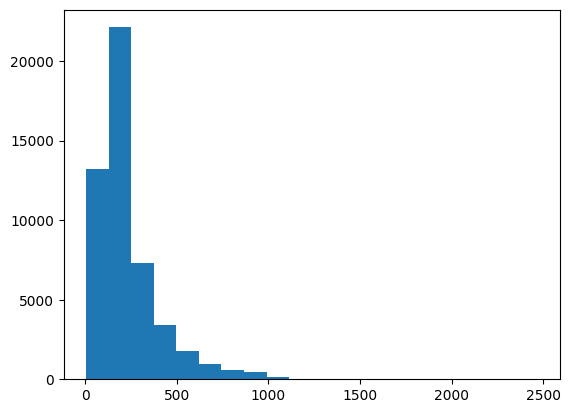

In [20]:
plt.hist(list_len,bins=20)
plt.show()

In [24]:
max_len

2466

In [22]:
np.average(list_len)

230.93754

In [23]:
np.median(list_len)

173.0

According to the 4 above outputs we can determine that we dont need almost 2200 more feauters. Its gonna produce more useless feauters and we can contorl it in pad_sequnce. We can set the max_len 200 or 240.

In [25]:
max_len

2466

Importing pad sequnece for padding all sentences to the same size using tje max_len 

In [26]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [28]:
max_len_light = 220

In [29]:
X = pad_sequences(encoded,maxlen=max_len_light,padding='post')

In [30]:
X

array([[    6,   432,  3182, ...,   124,  4102,   485],
       [    3,   392,   119, ...,     0,     0,     0],
       [    9,   189,    10, ...,     0,     0,     0],
       ...,
       [ 9567,  4388,    30, ..., 22824,     2,  6043],
       [  144,   165,     5, ...,     0,     0,     0],
       [   53,    26,  5889, ...,     0,     0,     0]])

In [31]:
X.shape

(50000, 220)

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [34]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding,Conv1D,MaxPool1D,Flatten,Dense,Dropout,Input
from tensorflow.keras.models import Sequential

In [35]:
reg = tf.keras.regularizers.l2(0.003)

In [36]:
model = Sequential()
model.add(Input(shape=(max_len_light,)))
model.add(Embedding(input_dim=vocab_len,output_dim=50,
                    embeddings_regularizer=reg))
model.add(Dropout(0.5))
model.add(Conv1D(filters=32,kernel_size=4,padding='same',activation='relu'))
model.add(Dropout(0.25))
model.add(MaxPool1D(pool_size=2))
model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 220, 50)        │     6,325,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 220, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 220, 32)        │         6,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 220, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 110, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3520)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       225,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,341 (25.01 MB)

 Trainable params: 6,557,341 (25.01 MB)

 Non-trainable params: 0 (0.00 B)

In model summary if you compare with the past version we have 2 million less parametrs and its goona decrease our fitting time (training time) and mybe increase accuracy

In [39]:
#compile model
opt = tf.optimizers.Adam(learning_rate=0.001)
loss = tf.losses.BinaryCrossentropy()
metric = [tf.metrics.BinaryAccuracy()]
model.compile(optimizer=opt,loss=loss,metrics=metric)

In [40]:
model.fit(X_train,y_train,batch_size=50,epochs=10,validation_split=0.2,verbose=2)

Epoch 1/10
640/640 - 70s - 110ms/step - binary_accuracy: 0.7475 - loss: 0.9618 - val_binary_accuracy: 0.8719 - val_loss: 0.5272
Epoch 2/10
640/640 - 85s - 134ms/step - binary_accuracy: 0.8724 - loss: 0.5466 - val_binary_accuracy: 0.8813 - val_loss: 0.5339
Epoch 3/10
640/640 - 80s - 126ms/step - binary_accuracy: 0.8813 - loss: 0.5427 - val_binary_accuracy: 0.8838 - val_loss: 0.5267
Epoch 4/10
640/640 - 78s - 123ms/step - binary_accuracy: 0.8845 - loss: 0.5407 - val_binary_accuracy: 0.8796 - val_loss: 0.5538
Epoch 5/10
640/640 - 73s - 114ms/step - binary_accuracy: 0.8891 - loss: 0.5364 - val_binary_accuracy: 0.8796 - val_loss: 0.5533
Epoch 6/10
640/640 - 72s - 112ms/step - binary_accuracy: 0.8923 - loss: 0.5350 - val_binary_accuracy: 0.8871 - val_loss: 0.5507
Epoch 7/10
640/640 - 68s - 106ms/step - binary_accuracy: 0.8950 - loss: 0.5340 - val_binary_accuracy: 0.8856 - val_loss: 0.5410
Epoch 8/10
640/640 - 53s - 83ms/step - binary_accuracy: 0.8984 - loss: 0.5279 - val_binary_accuracy: 0.8

In [41]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - binary_accuracy: 0.8910 - loss: 0.5359


[0.5358613729476929, 0.890999972820282]

Our accuracy is better than the last time and more important last time the fitting time was 24 mins and now its 11 mins. lets congratulations ourself.